# **Scikit**

En este apartado, se va a realizar el preprocesamiento de los datos limpios obtenidos después del ***Análisis Exploratorio de los Datos***. Posterior a ello, se implementará el modelo **MLP (Multilayer Perceptron) de Clasificación** con **SCIKIT**.

## **Librerías**

In [1]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")

## **Base de datos**

In [2]:
dataclean = pd.read_csv('../data/datalimpia.csv')

## **Preprocesamiento: Variables relevantes**

Es de interés identificar qué variables aportan más en este proceso de predicción. Sin embargo, para ello, hay que considerar distintos factores. Uno de los más importantes en este caso es el ***desbalanceo de la variable objetivo***, que 

In [3]:
X_brf = dataclean.drop('default', axis=1)
y_brf = dataclean['default']

In [4]:
ord_cols = ['grade', 'addr_state']
nom_cols = [col for col in X_brf.select_dtypes(include='object').columns if col not in ord_cols]


for col in ord_cols:
    X_brf[col] = LabelEncoder().fit_transform(X_brf[col])
    
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_nominal_encoded = pd.DataFrame(
    encoder.fit_transform(X_brf[nom_cols]),
    columns=encoder.get_feature_names_out(nom_cols)
)

X_preproc = pd.concat([X_brf.drop(columns=nom_cols).reset_index(drop=True),
                       X_nominal_encoded.reset_index(drop=True)], axis=1)

In [5]:
X_trainbrf, X_testbrf, y_trainbrf, y_testbrf = train_test_split(
    X_preproc, y_brf, test_size=0.2, stratify=y_brf, random_state=21)

In [6]:
brf = BalancedRandomForestClassifier(n_estimators=500, random_state=21,
                                     replacement=False, n_jobs=-1)

brf.fit(X_trainbrf, y_trainbrf)

importances = pd.Series(brf.feature_importances_, index=X_preproc.columns)
importances.sort_values(ascending=False, inplace=True)

threshold = 0.01

selected_features = importances[importances > threshold].index.tolist()

print("Cantidad de variables seleccionadas:", len(selected_features))
print("Variables seleccionadas:", selected_features)

Cantidad de variables seleccionadas: 22
Variables seleccionadas: ['dti', 'grade', 'tot_hi_cred_lim', 'annual_inc', 'funded_amnt', 'debt_settlement_flag_Y', 'total_il_high_credit_limit', 'addr_state', 'mths_since_recent_bc', 'num_il_tl', 'mo_sin_rcnt_rev_tl_op', 'mths_since_recent_inq', 'num_actv_rev_tl', 'mo_sin_rcnt_tl', 'emp_length', 'num_tl_op_past_12m', 'term', 'mort_acc', 'inq_last_6mths', 'tot_coll_amt', 'num_accts_ever_120_pd', 'delinq_2yrs']


Como resultado, se obtuvo que entre el conjunto total de datos disponibles, la información de **22** varias resultó ser la más siginificativa o relevante.

Ahora, vamos a implementar **MLP** con estas variables seleccionadas.

## **Modelo MLP**

In [7]:
X_final = X_preproc[selected_features].copy()

numcolsfinal = X_final.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_final[numcolsfinal] = scaler.fit_transform(X_final[numcolsfinal])

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_brf, test_size=0.2, random_state=21, stratify=y_brf
)

mlp = MLPClassifier(random_state=21)

param_grid = {
    'hidden_layer_sizes': [(10,), (50,), (100,)],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [100, 200]
}

grid_search = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid,
    scoring='recall',       
    cv=3,               
    n_jobs=-1,
    verbose=2
)

start_time = time.time()
grid_search.fit(X_train, y_train)
train_time = time.time() - start_time

best_mlp = grid_search.best_estimator_

start_pred = time.time()
y_pred = best_mlp.predict(X_test)
pred_time = time.time() - start_pred


Fitting 3 folds for each of 18 candidates, totalling 54 fits


In [32]:
probas = best_mlp.predict_proba(X_test)[:,1]

# Elegir un nuevo umbral menor para captar más defaults
umbral = 0.5
y_pred_adjusted = (probas >= umbral).astype(int)

### **Métricas y valores resultantes**

In [33]:
accuracy = accuracy_score(y_test, y_pred_adjusted)
precision = precision_score(y_test, y_pred_adjusted)
recall = recall_score(y_test, y_pred_adjusted)
f1 = f1_score(y_test, y_pred_adjusted)
roc_auc = roc_auc_score(y_test, probas)
cm = confusion_matrix(y_test, y_pred_adjusted)

print("Mejores hiperparámetros:", grid_search.best_params_)
print(f"Tiempo de entrenamiento: {train_time:.2f} s")
print(f"Tiempo de predicción: {pred_time:.2f} s")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("ROC AUC:", roc_auc)

Mejores hiperparámetros: {'alpha': 0.001, 'hidden_layer_sizes': (100,), 'max_iter': 100}
Tiempo de entrenamiento: 1574.87 s
Tiempo de predicción: 0.50 s
Accuracy: 0.8270064148783551
Precision: 0.7938330326390027
Recall: 0.18022043491212392
F1-score: 0.293751706976603
ROC AUC: 0.7535658655447877


### **Matriz de confusión**

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt

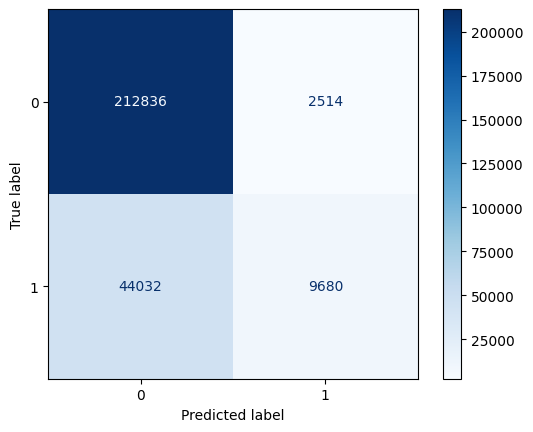

In [11]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap=plt.cm.Blues) 
plt.show()

### **Curva ROC**

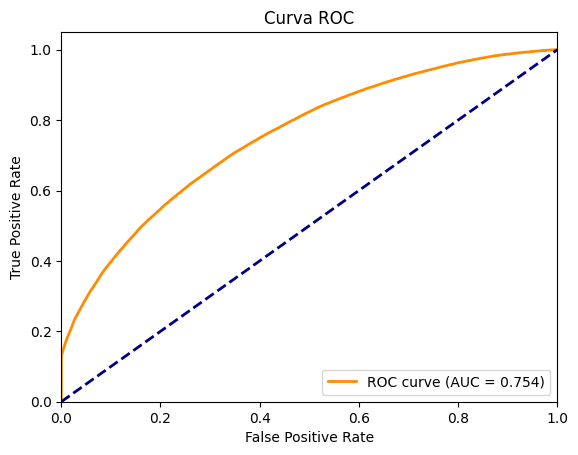

In [12]:
y_prob = best_mlp.predict_proba(X_test)[:, 1]  

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.3f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # línea diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

## **LIME**

In [19]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

In [20]:
y_test_np = y_test.values  # ahora es un array NumPy
misclassified_idx = np.where(y_pred != y_test_np)[0]

In [21]:
instances_to_explain = misclassified_idx[:2]


In [22]:
# Crear el explainer
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    class_names=['Fully Paid', 'Charged Off'],
    mode='classification'
)


In [23]:
# Explicar instancias
for idx in instances_to_explain:
    exp = explainer.explain_instance(
        data_row=X_test.iloc[idx].values,
        predict_fn=best_mlp.predict_proba
    )  

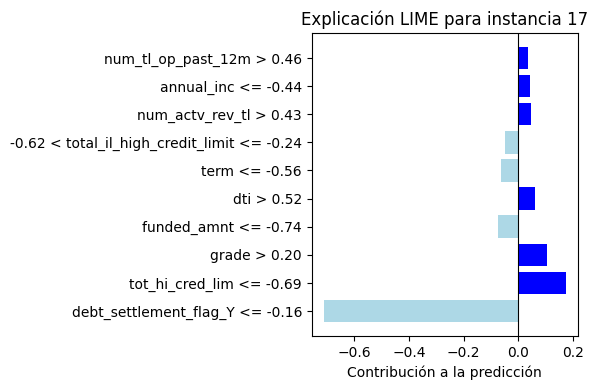

In [26]:
feature_names, contributions = zip(*exp.as_list())
    
    # Colores: verde positivo, rojo negativo
colors = ['blue' if c > 0 else 'lightblue' for c in contributions]
    
    # Gráfico de barras horizontal
plt.figure(figsize=(6,4))
plt.barh(feature_names, contributions, color=colors)
plt.xlabel('Contribución a la predicción')
plt.title(f'Explicación LIME para instancia {idx}')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()